In [1]:
import os
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

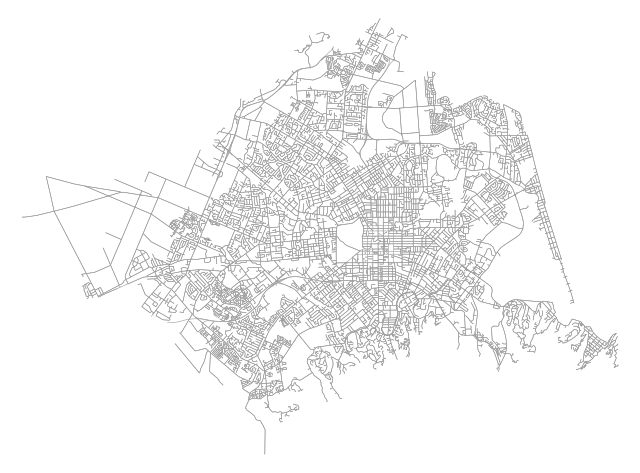

In [2]:
place_name = "Christchurch, New Zealand"
G = ox.graph_from_place(place_name, network_type="drive")
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.4,
    bgcolor="white"
)

In [3]:
tags = {
    "amenity": ["hospital", "clinic"],
    "shop": ["supermarket"]
}

pois = ox.features_from_place(place_name, tags)
pois.head()

len(pois), pois.columns.tolist()

(134,
 ['geometry',
  'branch',
  'brand',
  'brand:wikidata',
  'brand:wikipedia',
  'check_date',
  'name',
  'opening_hours',
  'phone',
  'shop',
  'website',
  'wheelchair',
  'amenity',
  'healthcare',
  'addr:city',
  'addr:country',
  'addr:postcode',
  'addr:street',
  'metroinfo:id',
  'operator',
  'toilets:wheelchair',
  'addr:housenumber',
  'payment:cash',
  'payment:credit_cards',
  'payment:debit_cards',
  'payment:visa',
  'wikidata',
  'addr:suburb',
  'ref:linz:address_id',
  'name:mi',
  'level',
  'bulk_purchase',
  'organic',
  'name:en',
  'healthcare:speciality',
  'contact:phone',
  'emergency',
  'operator:type',
  'addr:postbox',
  'description',
  'contact:facebook',
  'toilets',
  'diet:vegan',
  'diet:halal',
  'email',
  'fax',
  'phone:NZ',
  'check_date:opening_hours',
  'survey:date',
  'mobile',
  'addr:province',
  'addr:unit',
  'contact:email',
  'contact:fax',
  'contact:website',
  'payment:contactless',
  'payment:mastercard',
  'old_name',
  'c

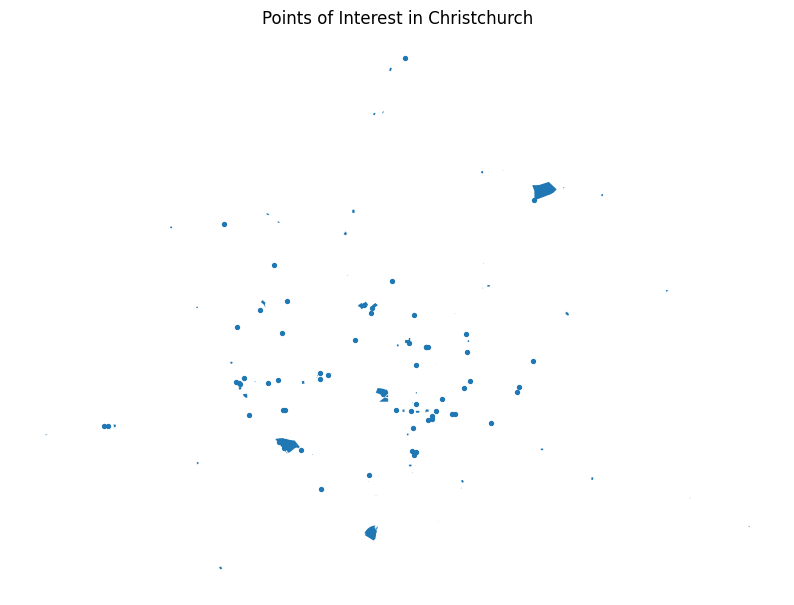

In [4]:
pois_plot = pois[pois.geometry.notnull()].copy()

fig, ax = plt.subplots(figsize=(10, 10))
pois_plot.plot(ax=ax, markersize=8)
ax.set_title("Points of Interest in Christchurch")
ax.set_axis_off()
plt.show()

In [6]:
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

ox.save_graphml(G, filepath="../data/raw/christchurch_drive.graphml")
pois.to_file("../data/raw/christchurch_pois.geojson", driver="GeoJSON")